In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

print("✓ Libraries loaded")

✓ Libraries loaded


In [2]:
# Load the precious modified file 
df = pd.read_csv('../data/cleaned_transactions.csv')

# Date column fixed which can be lost in csv file
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Customer loaded: {len(df)} rows")
print(f"Customers: {df['CustomerID'].nunique}")

Customer loaded: 392692 rows
Customers: <bound method IndexOpsMixin.nunique of 0         17850
1         17850
2         17850
3         17850
4         17850
          ...  
392687    12680
392688    12680
392689    12680
392690    12680
392691    12680
Name: CustomerID, Length: 392692, dtype: int64>


In [3]:
# We calculate "Recency" as "days since last purchase"
# We need a fixed "today" to measure from
# Using the day AFTER the last transaction in our data

reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(f"✓ Reference date (our 'today'): {reference_date.date()}")

✓ Reference date (our 'today'): 2011-12-10


In [4]:
# For each customer: how many days since their last purchase?

last_purchase = df.groupby('CustomerID')['InvoiceDate'].max()
recency = (reference_date - last_purchase).dt.days

print(f"  Recency calculated")
print(f"  Most recent customer: {recency.min()} days ago")
print(f"  Oldest customer: {recency.max()} days ago")

  Recency calculated
  Most recent customer: 1 days ago
  Oldest customer: 374 days ago


In [5]:
# For each customer: how many orders did they make total?

frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()

print(f"  Frequency calculated")
print(f"  Min orders: {frequency.min()}")
print(f"  Max orders: {frequency.max()}")
print(f"  Average: {frequency.mean():.1f}")

  Frequency calculated
  Min orders: 1
  Max orders: 209
  Average: 4.3


In [6]:
# For each customer: how much total money did they spend?

df_positive = df[df['Revenue'] > 0]  # Only count sales, not returns
monetary = df_positive.groupby('CustomerID')['Revenue'].sum()

print(f"  Monetary calculated")
print(f"  Min spent: £{monetary.min():.2f}")
print(f"  Max spent: £{monetary.max():,.2f}")
print(f"  Average: £{monetary.mean():,.2f}")

  Monetary calculated
  Min spent: £3.75
  Max spent: £280,206.02
  Average: £2,048.69


In [7]:
# Put all three together: Recency, Frequency, Monetary

rfm = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary
})

# Remove any customers with missing data
rfm = rfm.dropna()

# Reset index so CustomerID becomes a column
rfm = rfm.reset_index()

print(f"  RFM table created!")
print(f"  Total customers: {len(rfm):,}")
print()
print("First 5 customers:")
print(rfm.head())

  RFM table created!
  Total customers: 4,338

First 5 customers:
   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40


In [8]:
scaler = MinMaxScaler()

rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary']
)

print("  Data scaled to 0-1 range")

  Data scaled to 0-1 range


In [9]:
# Try k = 2, 3, 4, 5, 6, 7, 8
# For each k, measure how "tight" the clusters are

inertia_list = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia_list.append(kmeans.inertia_)
    print(f"k={k}: inertia={kmeans.inertia_:.2f}")

print("\n Tried all values from k=2 to k=8")

k=2: inertia=74.15
k=3: inertia=40.87
k=4: inertia=27.22
k=5: inertia=20.60
k=6: inertia=16.11
k=7: inertia=12.77
k=8: inertia=10.90

 Tried all values from k=2 to k=8


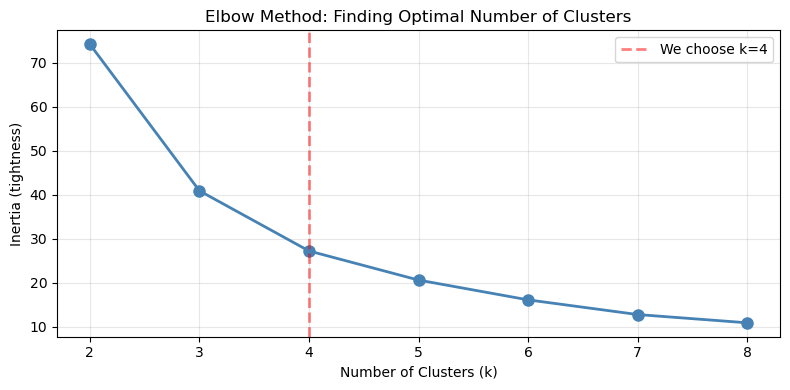

  Chart saved to: reports/01_elbow_chart.png


In [10]:
# Plot how inertia changes with different k values
# The "elbow" shows the best k

plt.figure(figsize=(8, 4))
plt.plot(range(2, 9), inertia_list, marker='o', linewidth=2, markersize=8, color='steelblue')
plt.axvline(x=4, color='red', linestyle='--', alpha=0.5, linewidth=2, label='We choose k=4')
plt.title('Elbow Method: Finding Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (tightness)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/01_elbow_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("  Chart saved to: reports/01_elbow_chart.png")

In [11]:
# Run K-Means clustering with 4 clusters
# random_state=42 means same results every time you run it
# n_init=10 means it tries 10 different starting points and picks best

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(rfm_scaled)

# Add cluster labels to our RFM table
rfm['Cluster'] = clusters

print(f"  Clustering complete!")
print()
print("How many customers in each cluster:")
print(rfm['Cluster'].value_counts().sort_index())
print()
print("First 10 customers with their cluster:")
print(rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster']].head(10))

  Clustering complete!

How many customers in each cluster:
Cluster
0    2207
1     599
2    1035
3     497
Name: count, dtype: int64

First 10 customers with their cluster:
   CustomerID  Recency  Frequency  Monetary  Cluster
0       12346      326          1  77183.60        3
1       12347        2          7   4310.00        0
2       12348       75          4   1797.24        2
3       12349       19          1   1757.55        0
4       12350      310          1    334.40        3
5       12352       36          8   2506.04        0
6       12353      204          1     89.00        1
7       12354      232          1   1079.40        1
8       12355      214          1    459.40        1
9       12356       23          3   2811.43        0


In [12]:
# Look at average RFM values per cluster
# This tells us what each cluster "looks like"

cluster_summary = rfm.groupby('Cluster').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Count=('CustomerID', 'count')
).round(1)

print("Cluster Summary (average values):")
print(cluster_summary)
print()
print("Interpretation guide:")
print("  Low Recency + High Frequency + High Monetary = VIP (buy recently, often, and a lot)")
print("  Low Recency + Medium Frequency + Medium Monetary = Loyal (buy recently and regularly)")
print("  High Recency + Low Frequency + Low Monetary = At-Risk (haven't bought in ages)")
print("  Low Recency + Low Frequency + Low Monetary = New (just started buying)")

Cluster Summary (average values):
         Avg_Recency  Avg_Frequency  Avg_Monetary  Count
Cluster                                                 
0               20.3            6.4        3233.9   2207
1              193.4            1.9         718.7    599
2               84.2            2.6        1003.5   1035
3              309.0            1.4         565.0    497

Interpretation guide:
  Low Recency + High Frequency + High Monetary = VIP (buy recently, often, and a lot)
  Low Recency + Medium Frequency + Medium Monetary = Loyal (buy recently and regularly)
  High Recency + Low Frequency + Low Monetary = At-Risk (haven't bought in ages)
  Low Recency + Low Frequency + Low Monetary = New (just started buying)


In [13]:
# Based on the RFM values, figure out which cluster is which segment

cluster_recency = rfm.groupby('Cluster')['Recency'].mean()
cluster_monetary = rfm.groupby('Cluster')['Monetary'].mean()
cluster_frequency = rfm.groupby('Cluster')['Frequency'].mean()

# VIP = highest spenders (highest monetary)
vip_cluster = cluster_monetary.idxmax()

# At-Risk = haven't bought recently (highest recency)
at_risk_cluster = cluster_recency.idxmax()

# Find New and Loyal from the remaining clusters
remaining = [c for c in [0, 1, 2, 3] if c not in [vip_cluster, at_risk_cluster]]

# New = lowest frequency (least orders)
new_cluster = rfm[rfm['Cluster'].isin(remaining)].groupby('Cluster')['Frequency'].mean().idxmin()

# Loyal = the one left over
loyal_cluster = [c for c in remaining if c != new_cluster][0]

# Create mapping
segment_map = {
    vip_cluster: 'VIP',
    loyal_cluster: 'Loyal',
    new_cluster: 'New',
    at_risk_cluster: 'At-Risk'
}

print("Segment Assignment:")
for cluster_num, segment_name in segment_map.items():
    print(f"  Cluster {cluster_num} → {segment_name}")

Segment Assignment:
  Cluster 0 → VIP
  Cluster 2 → Loyal
  Cluster 1 → New
  Cluster 3 → At-Risk


In [14]:
# Map cluster numbers to segment names
rfm['Segment'] = rfm['Cluster'].map(segment_map)

print("  Segments assigned!")
print()
print("Customer count per segment:")
print(rfm['Segment'].value_counts())
print()
print("First 10 customers with segments:")
print(rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Segment']].head(10))

  Segments assigned!

Customer count per segment:
Segment
VIP        2207
Loyal      1035
New         599
At-Risk     497
Name: count, dtype: int64

First 10 customers with segments:
   CustomerID  Recency  Frequency  Monetary  Segment
0       12346      326          1  77183.60  At-Risk
1       12347        2          7   4310.00      VIP
2       12348       75          4   1797.24    Loyal
3       12349       19          1   1757.55      VIP
4       12350      310          1    334.40  At-Risk
5       12352       36          8   2506.04      VIP
6       12353      204          1     89.00      New
7       12354      232          1   1079.40      New
8       12355      214          1    459.40      New
9       12356       23          3   2811.43      VIP


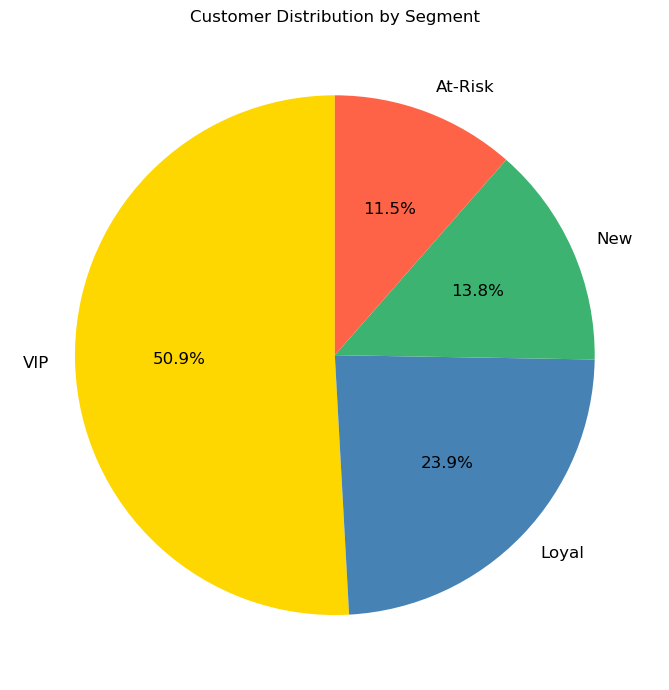

  Chart saved to: reports/02_segment_pie.png


In [15]:
# Show what % of customers are in each segment

segment_counts = rfm['Segment'].value_counts()

colors = {
    'VIP': 'gold',
    'Loyal': 'steelblue',
    'New': 'mediumseagreen',
    'At-Risk': 'tomato'
}

color_list = [colors.get(s, 'gray') for s in segment_counts.index]

plt.figure(figsize=(7, 7))
plt.pie(
    segment_counts.values,
    labels=segment_counts.index,
    autopct='%1.1f%%',
    colors=color_list,
    startangle=90,
    textprops={'fontsize': 12}
)
plt.title('Customer Distribution by Segment')
plt.tight_layout()
plt.savefig('../reports/02_segment_pie.png', dpi=150, bbox_inches='tight')
plt.show()

print("  Chart saved to: reports/02_segment_pie.png")

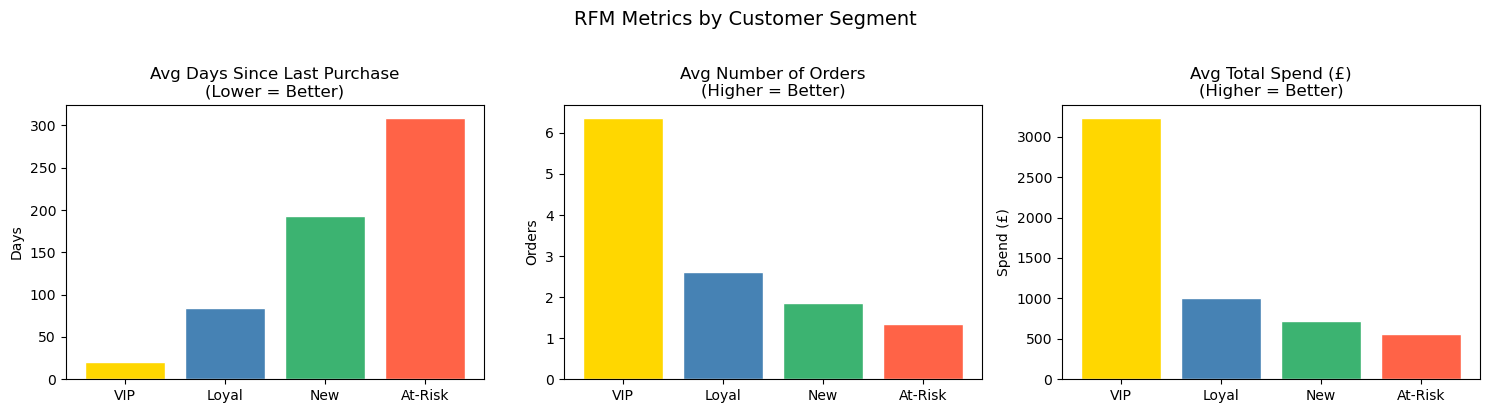

✓ Chart saved to: reports/03_segment_comparison.png


In [16]:
# Compare average RFM values across segments

segment_rfm = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean()

# Reorder segments for better visual
segment_order = ['VIP', 'Loyal', 'New', 'At-Risk']
segment_rfm = segment_rfm.reindex(segment_order)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors_list = [colors[s] for s in segment_order]

# Recency (lower is better — more recent = better customer)
axes[0].bar(segment_order, segment_rfm['Recency'], color=colors_list, edgecolor='white')
axes[0].set_title('Avg Days Since Last Purchase\n(Lower = Better)')
axes[0].set_ylabel('Days')

# Frequency (higher is better — more orders = better)
axes[1].bar(segment_order, segment_rfm['Frequency'], color=colors_list, edgecolor='white')
axes[1].set_title('Avg Number of Orders\n(Higher = Better)')
axes[1].set_ylabel('Orders')

# Monetary (higher is better — more money = better)
axes[2].bar(segment_order, segment_rfm['Monetary'], color=colors_list, edgecolor='white')
axes[2].set_title('Avg Total Spend (£)\n(Higher = Better)')
axes[2].set_ylabel('Spend (£)')

plt.suptitle('RFM Metrics by Customer Segment', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../reports/03_segment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Chart saved to: reports/03_segment_comparison.png")

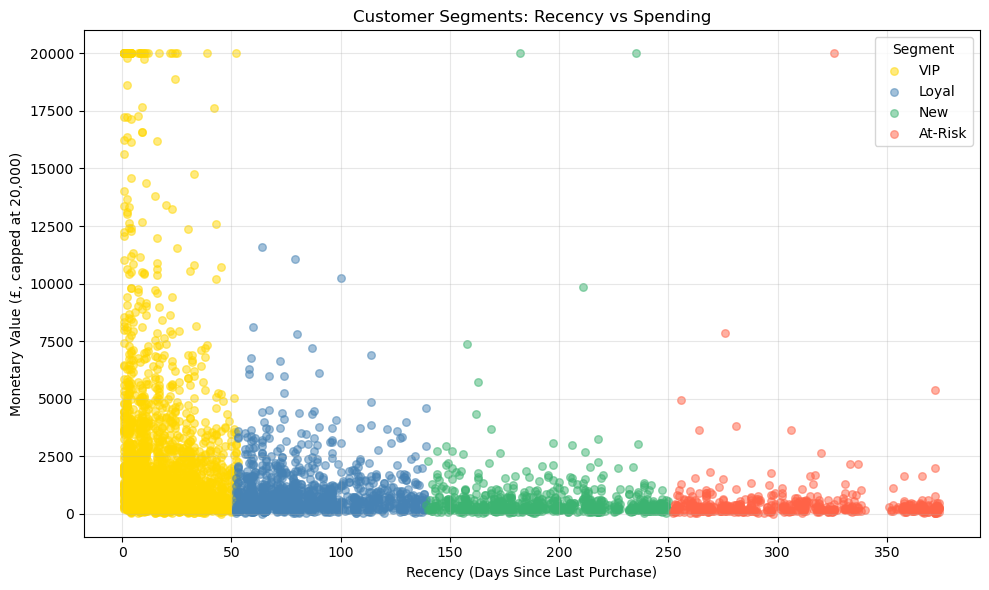

  Chart saved to: reports/04_segment_scatter.png


In [17]:
# Visualize segments on a scatter plot

plt.figure(figsize=(10, 6))

for segment in ['VIP', 'Loyal', 'New', 'At-Risk']:
    segment_data = rfm[rfm['Segment'] == segment]
    
    # Cap monetary at 20,000 so chart is readable
    monetary_capped = segment_data['Monetary'].clip(upper=20000)
    
    plt.scatter(
        segment_data['Recency'],
        monetary_capped,
        label=segment,
        color=colors[segment],
        alpha=0.5,
        s=30
    )

plt.xlabel('Recency (Days Since Last Purchase)')
plt.ylabel('Monetary Value (£, capped at 20,000)')
plt.title('Customer Segments: Recency vs Spending')
plt.legend(title='Segment')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/04_segment_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("  Chart saved to: reports/04_segment_scatter.png")

In [18]:
print("\n" + "="*70)
print("CUSTOMER SEGMENTS — BUSINESS INSIGHTS & RECOMMENDATIONS")
print("="*70)

for segment in ['VIP', 'Loyal', 'New', 'At-Risk']:
    seg_data = rfm[rfm['Segment'] == segment]
    
    count = len(seg_data)
    avg_rec = seg_data['Recency'].mean()
    avg_freq = seg_data['Frequency'].mean()
    avg_mon = seg_data['Monetary'].mean()
    pct_revenue = seg_data['Monetary'].sum() / rfm['Monetary'].sum() * 100

    print(f"\n{'-'*70}")
    print(f"SEGMENT: {segment.upper()}")
    print(f"{'-'*70}")
    print(f"  Customers:          {count:,} ({count/len(rfm)*100:.1f}% of total)")
    print(f"  Avg Days Since Buy: {avg_rec:.0f} days")
    print(f"  Avg Orders:         {avg_freq:.1f} orders")
    print(f"  Avg Spend:          £{avg_mon:,.0f}")
    print(f"  % of Total Revenue: {pct_revenue:.1f}%")

    # Recommendation per segment
    if segment == 'VIP':
        print(f"  ACTION: Send exclusive offers, early access to new products")
        print(f"  GOAL: Retain them — they drive most of your revenue")
    
    elif segment == 'Loyal':
        print(f"  ACTION: Upsell recommendations, loyalty rewards program")
        print(f"  GOAL: Move them to VIP tier by increasing their spend")
    
    elif segment == 'New':
        print(f"  ACTION: Welcome email, 10% discount on 2nd purchase")
        print(f"  GOAL: Turn one-time buyers into repeat customers")
    
    elif segment == 'At-Risk':
        print(f"  ACTION: Winback email with strong discount (20-30% off)")
        print(f"  GOAL: Re-engage before they're lost forever")

print("\n" + "="*70)


CUSTOMER SEGMENTS — BUSINESS INSIGHTS & RECOMMENDATIONS

----------------------------------------------------------------------
SEGMENT: VIP
----------------------------------------------------------------------
  Customers:          2,207 (50.9% of total)
  Avg Days Since Buy: 20 days
  Avg Orders:         6.4 orders
  Avg Spend:          £3,234
  % of Total Revenue: 80.3%
  ACTION: Send exclusive offers, early access to new products
  GOAL: Retain them — they drive most of your revenue

----------------------------------------------------------------------
SEGMENT: LOYAL
----------------------------------------------------------------------
  Customers:          1,035 (23.9% of total)
  Avg Days Since Buy: 84 days
  Avg Orders:         2.6 orders
  Avg Spend:          £1,004
  % of Total Revenue: 11.7%
  ACTION: Upsell recommendations, loyalty rewards program
  GOAL: Move them to VIP tier by increasing their spend

--------------------------------------------------------------------

In [19]:
# Save the RFM table with segment labels
# Note: we will also save a richer version (customer_features.csv) at the end

rfm.to_csv('../data/rfm_segments.csv', index=False)

print("✓ Saved: data/rfm_segments.csv")
print()
print("File contains:")
print(f"  - {len(rfm):,} customers")
print(f"  - Columns: CustomerID, Recency, Frequency, Monetary, Cluster, Segment")

✓ Saved: data/rfm_segments.csv

File contains:
  - 4,338 customers
  - Columns: CustomerID, Recency, Frequency, Monetary, Cluster, Segment


In [20]:
print("=" * 70)
print("FEATURE ENGINEERING + CHURN LABEL + TRAIN-TEST SPLIT")
print("=" * 70)
print()
print("We now add 4 extra features, create the churn label,")

FEATURE ENGINEERING + CHURN LABEL + TRAIN-TEST SPLIT

We now add 4 extra features, create the churn label,


In [21]:
# FEATURE 1: AOV (Average Order Value)
# How much does the customer spend per order on average?

# Total revenue per customer (positive sales only)
total_revenue = df[df['Revenue'] > 0].groupby('CustomerID')['Revenue'].sum()

# Number of orders per customer
total_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()

# AOV = revenue / orders
aov = (total_revenue / total_orders).round(2)
aov.name = 'AOV'

print("  AOV calculated")
print(f"  Lowest AOV:  £{aov.min():.2f}")
print(f"  Highest AOV: £{aov.max():,.2f}")
print(f"  Average AOV: £{aov.mean():,.2f}")

  AOV calculated
  Lowest AOV:  £3.45
  Highest AOV: £84,236.25
  Average AOV: £417.65


In [22]:
# FEATURE 2: Tenure (Days Active)
# How long has this customer been with us?
# Days between their FIRST and LAST purchase.

first_purchase = df.groupby('CustomerID')['InvoiceDate'].min()
last_purchase  = df.groupby('CustomerID')['InvoiceDate'].max()

tenure = (last_purchase - first_purchase).dt.days
tenure.name = 'Tenure'

print("  Tenure calculated")
print(f"  Shortest tenure: {tenure.min()} days")
print(f"  Longest tenure:  {tenure.max()} days")
print(f"  Average tenure:  {tenure.mean():.0f} days")
print()
print("Note: Tenure = 0 means they only bought once (same day)")

  Tenure calculated
  Shortest tenure: 0 days
  Longest tenure:  373 days
  Average tenure:  130 days

Note: Tenure = 0 means they only bought once (same day)


In [23]:
# FEATURE 3: Product Diversity
# How many DIFFERENT products has this customer bought?

product_diversity = df.groupby('CustomerID')['StockCode'].nunique()
product_diversity.name = 'ProductDiversity'

print("   Product Diversity calculated-")
print(f"  Min unique products: {product_diversity.min()}")
print(f"  Max unique products: {product_diversity.max()}")
print(f"  Average: {product_diversity.mean():.1f} unique products per customer")

   Product Diversity calculated-
  Min unique products: 1
  Max unique products: 1787
  Average: 61.5 unique products per customer


In [24]:
# Load raw uncleaned data to calculate return rate
# (cleaned_transactions has no negative quantities)
df_raw = pd.read_excel('../data/Online Retail.xlsx', dtype={'CustomerID': str}, engine='openpyxl')
df_raw.dropna(subset=['CustomerID'], inplace=True)
df_raw['CustomerID'] = df_raw['CustomerID'].astype(int)

In [25]:
# FEATURE 4: Return Rate
# What percentage of transactions were returns?
# High return rate = possibly unhappy customer = higher churn risk

total_transactions  = df_raw.groupby('CustomerID')['InvoiceNo'].count()
return_transactions = df_raw[df_raw['Quantity'] < 0].groupby('CustomerID')['InvoiceNo'].count()

# Fill 0 for customers who never returned anything
return_transactions = return_transactions.reindex(total_transactions.index, fill_value=0)

return_rate = (return_transactions / total_transactions).round(4)
return_rate.name = 'ReturnRate'

print("  Return Rate calculated")
print(f"  Customers with 0% return rate: {(return_rate == 0).sum():,}")
print(f"  Max return rate: {return_rate.max():.1%}")
print(f"  Average return rate: {return_rate.mean():.1%}")

  Return Rate calculated
  Customers with 0% return rate: 2,783
  Max return rate: 100.0%
  Average return rate: 3.2%


In [26]:
# Merge all 4 new features into rfm
rfm = rfm.set_index('CustomerID')
rfm = rfm.join(aov)
rfm = rfm.join(tenure)
rfm = rfm.join(product_diversity)
rfm = rfm.join(return_rate)
rfm = rfm.reset_index()

print("✓ All features merged into rfm")
print("Columns:", rfm.columns.tolist())
print(rfm.head(3))

✓ All features merged into rfm
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment', 'AOV', 'Tenure', 'ProductDiversity', 'ReturnRate']
   CustomerID  Recency  Frequency  Monetary  Cluster  Segment       AOV  \
0       12346      326          1  77183.60        3  At-Risk  77183.60   
1       12347        2          7   4310.00        0      VIP    615.71   
2       12348       75          4   1797.24        2    Loyal    449.31   

   Tenure  ProductDiversity  ReturnRate  
0       0                 1         0.5  
1     365               103         0.0  
2     282                22         0.0  


In [27]:
# Remove outliers using IQR (3x)
Q1 = rfm[['Frequency', 'Monetary', 'AOV', 'ProductDiversity']].quantile(0.25)
Q3 = rfm[['Frequency', 'Monetary', 'AOV', 'ProductDiversity']].quantile(0.75)
IQR = Q3 - Q1

mask = ~((rfm[['Frequency', 'Monetary', 'AOV', 'ProductDiversity']] < (Q1 - 3 * IQR)) |
         (rfm[['Frequency', 'Monetary', 'AOV', 'ProductDiversity']] > (Q3 + 3 * IQR))).any(axis=1)

print(f"Customers before: {len(rfm)}")
print(f"Outliers removed: {(~mask).sum()}")

rfm = rfm[mask].copy()

# Scale 4 features (no Recency)
scaler2 = MinMaxScaler()
rfm_scaled2 = scaler2.fit_transform(rfm[['Frequency', 'Monetary', 'AOV', 'ProductDiversity']])
rfm_scaled2 = pd.DataFrame(rfm_scaled2, columns=['Frequency', 'Monetary', 'AOV', 'ProductDiversity'])

# KMeans with 4 clusters
kmeans2 = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans2.fit_predict(rfm_scaled2)

# Assign segment names
cluster_monetary  = rfm.groupby('Cluster')['Monetary'].mean()
cluster_recency   = rfm.groupby('Cluster')['Recency'].mean()
cluster_frequency = rfm.groupby('Cluster')['Frequency'].mean()

vip_cluster     = cluster_monetary.idxmax()
at_risk_cluster = cluster_recency.idxmax()
remaining       = [c for c in [0,1,2,3] if c not in [vip_cluster, at_risk_cluster]]
new_cluster     = rfm[rfm['Cluster'].isin(remaining)].groupby('Cluster')['Frequency'].mean().idxmin()
loyal_cluster   = [c for c in remaining if c != new_cluster][0]

segment_map = {
    vip_cluster:     'VIP',
    loyal_cluster:   'Loyal',
    new_cluster:     'New',
    at_risk_cluster: 'At-Risk'
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

print("\nCluster → Segment mapping:")
for k, v in segment_map.items():
    print(f"  Cluster {k} → {v}")

print("\nCluster sizes:")
print(rfm['Cluster'].value_counts().sort_index())

Customers before: 4338
Outliers removed: 375

Cluster → Segment mapping:
  Cluster 1 → VIP
  Cluster 3 → Loyal
  Cluster 2 → New
  Cluster 0 → At-Risk

Cluster sizes:
Cluster
0    2169
1     437
2     513
3     844
Name: count, dtype: int64


In [28]:
rfm['Churned'] = (rfm['Recency'] > 90).astype(int)

print(f"✓ Churned = Recency > 90 days")
print(rfm['Churned'].value_counts())
print(f"Churn rate: {rfm['Churned'].mean()*100:.1f}%")
print()
print(pd.crosstab(rfm['Cluster'], rfm['Churned'], margins=True))

✓ Churned = Recency > 90 days
Churned
0    2557
1    1406
Name: count, dtype: int64
Churn rate: 35.5%

Churned     0     1   All
Cluster                  
0        1108  1061  2169
1         413    24   437
2         305   208   513
3         731   113   844
All      2557  1406  3963


In [29]:
print("CHURN DISTRIBUTION:")
print(rfm['Churned'].value_counts())
print(f"\nChurn rate: {rfm['Churned'].mean()*100:.1f}%")

print("\n" + "="*60)
print("CHURN BY TENURE:")
print("="*60)

# Check how churn changes by tenure
tenure_bins = [0, 30, 90, 365]
tenure_labels = ['Very New (0-30d)', 'Somewhat New (30-90d)', 'Established (90+d)']
rfm['TenureGroup'] = pd.cut(rfm['Tenure'], bins=tenure_bins, labels=tenure_labels, right=False)

print(rfm.groupby('TenureGroup')['Churned'].agg(['count', 'sum', 'mean']))
print("\nChurn rate by tenure group:")
print((rfm.groupby('TenureGroup')['Churned'].mean() * 100).round(1))

# Remove the TenureGroup column (it was just for analysis)
rfm = rfm.drop(columns=['TenureGroup'])

print("✓ Temporary columns removed")

CHURN DISTRIBUTION:
Churned
0    2557
1    1406
Name: count, dtype: int64

Churn rate: 35.5%

CHURN BY TENURE:
                       count  sum      mean
TenureGroup                                
Very New (0-30d)        1676  914  0.545346
Somewhat New (30-90d)    401  149  0.371571
Established (90+d)      1851  343  0.185305

Churn rate by tenure group:
TenureGroup
Very New (0-30d)         54.5
Somewhat New (30-90d)    37.2
Established (90+d)       18.5
Name: Churned, dtype: float64
✓ Temporary columns removed


C:\Users\gagan\AppData\Local\Temp\ipykernel_27944\3918370352.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(rfm.groupby('TenureGroup')['Churned'].agg(['count', 'sum', 'mean']))
C:\Users\gagan\AppData\Local\Temp\ipykernel_27944\3918370352.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print((rfm.groupby('TenureGroup')['Churned'].mean() * 100).round(1))


In [30]:
churn_counts = rfm['Churned'].value_counts()
churn_rate = rfm['Churned'].mean() * 100

print(f"Overall churn rate: {churn_rate:.1f}%")
print()

if churn_rate > 80:
    print("⚠️  Warning: Too many churned customers (>80%)")
    print("   Consider LOWERING threshold to 60 days")
elif churn_rate < 20:
    print("⚠️  Warning: Too few churned customers (<20%)")
    print("   Consider RAISING threshold to 120 days")
else:
    print("✓ Good balance! Churn rate is between 20-80%")
    print("  This is healthy for training a model")

Overall churn rate: 35.5%

✓ Good balance! Churn rate is between 20-80%
  This is healthy for training a model


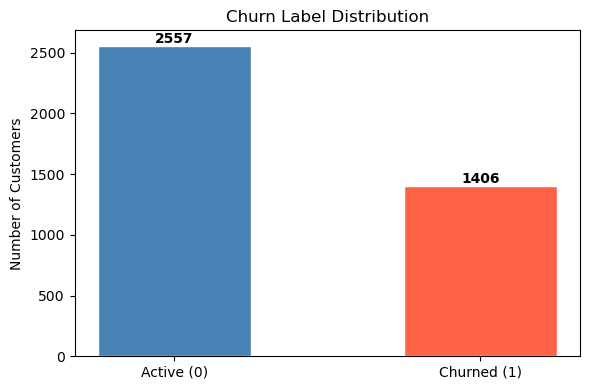

  Chart saved: reports/05_churn_distribution.png


In [31]:
labels = ['Active (0)', 'Churned (1)']
values = [churn_counts[0], churn_counts[1]]
colors_churn = ['steelblue', 'tomato']

plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=colors_churn, edgecolor='white', width=0.5)
plt.title('Churn Label Distribution')
plt.ylabel('Number of Customers')

for i, v in enumerate(values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/05_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("  Chart saved: reports/05_churn_distribution.png")

In [32]:
# Sanity check: At-Risk should have HIGH churn, VIP should have LOW churn

churn_by_segment = rfm.groupby('Segment')['Churned'].mean() * 100

print("Churn Rate by Segment:")
for segment, rate in churn_by_segment.sort_values(ascending=False).items():
    bar = '█' * int(rate / 5)
    print(f"  {segment:10}: {rate:5.1f}%  {bar}")

print()
print("✓ At-Risk should have highest churn, VIP should have lowest")

Churn Rate by Segment:
  At-Risk   :  48.9%  █████████
  New       :  40.5%  ████████
  Loyal     :  13.4%  ██
  VIP       :   5.5%  █

✓ At-Risk should have highest churn, VIP should have lowest


In [33]:
print("=== COMPLETE FEATURE TABLE ===")
print()
print(f"Total customers: {len(rfm):,}")
print(f"Total columns:   {len(rfm.columns)}")
print()

feature_descriptions = {
    'CustomerID':       'Unique customer identifier',
    'Recency':          'Days since last purchase (lower = better)',
    'Frequency':        'Number of orders placed',
    'Monetary':         'Total money spent (£)',
    'AOV':              'Average spend per order (£)',
    'Tenure':           'Days between first and last purchase',
    'ProductDiversity': 'Number of unique products bought',
    'ReturnRate':       'Fraction of transactions that were returns',
    'Cluster':          'K-Means cluster number (0-3)',
    'Segment':          'Segment label (VIP, Loyal, New, At-Risk)',
    'Churned':          'TARGET: 1 = churned, 0 = active'
}

for col, desc in feature_descriptions.items():
    if col in rfm.columns:
        print(f"  {col:20}: {desc}")

print()
print(rfm.head())

=== COMPLETE FEATURE TABLE ===

Total customers: 3,963
Total columns:   11

  CustomerID          : Unique customer identifier
  Recency             : Days since last purchase (lower = better)
  Frequency           : Number of orders placed
  Monetary            : Total money spent (£)
  AOV                 : Average spend per order (£)
  Tenure              : Days between first and last purchase
  ProductDiversity    : Number of unique products bought
  ReturnRate          : Fraction of transactions that were returns
  Cluster             : K-Means cluster number (0-3)
  Segment             : Segment label (VIP, Loyal, New, At-Risk)
  Churned             : TARGET: 1 = churned, 0 = active

   CustomerID  Recency  Frequency  Monetary  Cluster  Segment     AOV  Tenure  \
1       12347        2          7   4310.00        1      VIP  615.71     365   
2       12348       75          4   1797.24        2      New  449.31     282   
4       12350      310          1    334.40        0  At-R

In [34]:
print("Missing values check:")
missing = rfm.isnull().sum()

if missing.sum() == 0:
    print(" No missing values — clean and ready!")
else:
    print(missing[missing > 0])
    print("\nFilling missing values with 0...")
    rfm = rfm.fillna(0)
    print(" Fixed!")

Missing values check:
 No missing values — clean and ready!


In [35]:
# Separate features (X) from target label (y)
# Drop columns that aren't features for the model

X = rfm.drop(columns=['CustomerID', 'Segment', 'Churned'])
y = rfm['Churned']

print(f"Feature matrix X: {X.shape[0]} customers × {X.shape[1]} features")
print()
print("Features going into the model:")
print(X.columns.tolist())
print()
print(f"Target (y): {y.sum()} churned, {len(y) - y.sum()} active")

Feature matrix X: 3963 customers × 8 features

Features going into the model:
['Recency', 'Frequency', 'Monetary', 'Cluster', 'AOV', 'Tenure', 'ProductDiversity', 'ReturnRate']

Target (y): 1406 churned, 2557 active


In [36]:
# 80% train, 20% test
# stratify=y keeps the same churn ratio in both sets
# random_state=42 gives same split every run

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("  Train-Test split done!")
print()
print(f"Training set:  {len(X_train):,} customers  |  Churn rate: {y_train.mean()*100:.1f}%")
print(f"Test set:      {len(X_test):,}  customers  |  Churn rate: {y_test.mean()*100:.1f}%")
print()
print("  Churn rate is similar in both sets (that's what stratify=y does)")

  Train-Test split done!

Training set:  3,170 customers  |  Churn rate: 35.5%
Test set:      793  customers  |  Churn rate: 35.4%

  Churn rate is similar in both sets (that's what stratify=y does)


In [37]:
# Save full feature table
rfm.to_csv('../data/customer_features.csv', index=False)
print("  Saved: data/customer_features.csv")

# Save train set
train_set = X_train.copy()
train_set['Churned'] = y_train.values
train_set.to_csv('../data/train_set.csv', index=False)
print("  Saved: data/train_set.csv")

# Save test set
test_set = X_test.copy()
test_set['Churned'] = y_test.values
test_set.to_csv('../data/test_set.csv', index=False)
print("  Saved: data/test_set.csv")

  Saved: data/customer_features.csv
  Saved: data/train_set.csv
  Saved: data/test_set.csv


In [38]:
# Open 02_rfm_segmentation.ipynb
# Run ALL existing cells first (Kernel → Restart & Run All)
# Then add and run this cell at the bottom:

import joblib, os
os.makedirs('../saved_models', exist_ok=True)

# Save the KMeans model
joblib.dump(kmeans, '../saved_models/kmeans_model.pkl')

# Save the MinMaxScaler
joblib.dump(scaler, '../saved_models/clustering_scaler.pkl')

# Save cluster profiles (average RFM per segment)
cluster_profiles = rfm.groupby('Segment')[
    ['Frequency', 'Monetary', 'AOV', 'Tenure', 'ProductDiversity', 'ReturnRate']
].mean().round(2).to_dict()

joblib.dump(cluster_profiles, '../saved_models/cluster_profiles.pkl')
joblib.dump(segment_map,      '../saved_models/segment_map.pkl')

print("✓ Saved: kmeans_model.pkl")
print("✓ Saved: clustering_scaler.pkl")
print("✓ Saved: cluster_profiles.pkl")
print("✓ Saved: segment_map.pkl")

✓ Saved: kmeans_model.pkl
✓ Saved: clustering_scaler.pkl
✓ Saved: cluster_profiles.pkl
✓ Saved: segment_map.pkl


In [39]:
print("=" * 60)
print("NOTEBOOK COMPLETE — FULL SUMMARY")
print("=" * 60)

print(f"""
Phase 2 — RFM Segmentation:
  ✓ Recency, Frequency, Monetary calculated
  ✓ K-Means clustering (k=4)
  ✓ Segments: VIP, Loyal, New, At-Risk
  ✓ 4 charts saved to reports/

Phase 2.5 — Feature Engineering + Churn:
  ✓ AOV              (avg spend per order)
  ✓ Tenure           (days active as customer)
  ✓ ProductDiversity (unique products bought)
  ✓ ReturnRate       (fraction of returns)

Train-Test Split:
  ✓ Train: {len(train_set):,} customers
  ✓ Test:  {len(test_set):,} customers

Files Saved:
  ✓ data/rfm_segments.csv
  ✓ data/customer_features.csv
  ✓ data/train_set.csv
  ✓ data/test_set.csv
  ✓ reports/05_churn_distribution.png
""")

print("=" * 60)

NOTEBOOK COMPLETE — FULL SUMMARY

Phase 2 — RFM Segmentation:
  ✓ Recency, Frequency, Monetary calculated
  ✓ K-Means clustering (k=4)
  ✓ Segments: VIP, Loyal, New, At-Risk
  ✓ 4 charts saved to reports/

Phase 2.5 — Feature Engineering + Churn:
  ✓ AOV              (avg spend per order)
  ✓ Tenure           (days active as customer)
  ✓ ProductDiversity (unique products bought)
  ✓ ReturnRate       (fraction of returns)

Train-Test Split:
  ✓ Train: 3,170 customers
  ✓ Test:  793 customers

Files Saved:
  ✓ data/rfm_segments.csv
  ✓ data/customer_features.csv
  ✓ data/train_set.csv
  ✓ data/test_set.csv
  ✓ reports/05_churn_distribution.png



In [40]:
# ============================================================
# SAVE TRAIN AND TEST SETS
# ============================================================

# Remove temporary columns
rfm = rfm.drop(columns=['TenureGroup'], errors='ignore')

print("Preparing to save train/test sets...")
print()

# Split 80/20 (stratified by churn for balance)
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(
    rfm, 
    test_size=0.2, 
    random_state=42,
    stratify=rfm['Churned']
)

print(f"Train set: {len(train_set):,} customers")
print(f"Test set:  {len(test_set):,} customers")
print()

# SAVE TO CSV
train_set.to_csv('../data/train_set.csv', index=False)
test_set.to_csv('../data/test_set.csv', index=False)

print("✓ train_set.csv saved successfully")
print("✓ test_set.csv saved successfully")
print()

print("="*60)
print("VERIFICATION:")
print("="*60)

print(f"\nTrain set churn distribution:")
print(f"  Active (0):  {(train_set['Churned']==0).sum():,} customers")
print(f"  Churned (1): {(train_set['Churned']==1).sum():,} customers")
print(f"  Churn rate: {train_set['Churned'].mean()*100:.1f}%")

print(f"\nTest set churn distribution:")
print(f"  Active (0):  {(test_set['Churned']==0).sum():,} customers")
print(f"  Churned (1): {(test_set['Churned']==1).sum():,} customers")
print(f"  Churn rate: {test_set['Churned'].mean()*100:.1f}%")

print(f"\n--- Churn by Tenure in Train Set ---")
train_tenure_bins = [0, 30, 90, 365]
train_tenure_labels = ['Very New (0-30d)', 'Somewhat New (30-90d)', 'Established (90+d)']
train_set_copy = train_set.copy()
train_set_copy['TenureGroup'] = pd.cut(train_set_copy['Tenure'], bins=train_tenure_bins, labels=train_tenure_labels, right=False)
print(train_set_copy.groupby('TenureGroup', observed=True)['Churned'].mean() * 100)

print(f"\nCluster 1 (New) in train:")
cluster1_train = train_set[train_set['Cluster']==1]
print(f"  Count: {len(cluster1_train)}")
print(f"  Churn rate: {cluster1_train['Churned'].mean()*100:.1f}%")

print(f"\nCluster 0 (VIP) in train:")
cluster0_train = train_set[train_set['Cluster']==0]
print(f"  Count: {len(cluster0_train)}")
print(f"  Churn rate: {cluster0_train['Churned'].mean()*100:.1f}%")

Preparing to save train/test sets...

Train set: 3,170 customers
Test set:  793 customers

✓ train_set.csv saved successfully
✓ test_set.csv saved successfully

VERIFICATION:

Train set churn distribution:
  Active (0):  2,045 customers
  Churned (1): 1,125 customers
  Churn rate: 35.5%

Test set churn distribution:
  Active (0):  512 customers
  Churned (1): 281 customers
  Churn rate: 35.4%

--- Churn by Tenure in Train Set ---
TenureGroup
Very New (0-30d)         54.081633
Somewhat New (30-90d)    35.825545
Established (90+d)       18.482759
Name: Churned, dtype: float64

Cluster 1 (New) in train:
  Count: 337
  Churn rate: 6.5%

Cluster 0 (VIP) in train:
  Count: 1766
  Churn rate: 48.4%
